# ファクター検証　（reprisk）

`input/msci_india_imi/alpha/reprisk/repr_current_rri`（RepRisk Index, RRI）の検証

## 固有リターン（srtn）による再検証

### 目的

`06_regime` では `rtn`（トータルリターン）で「RRI 25 以上の劣後」が 2008〜2017 年に存在し、業種中立にすると半分に減ることを見た。
ここではリターンを BARRA GEMLT の**固有リターン** `srtn`（業種・国・スタイルなど全ファクターの寄与を除いた残差）に替えて
同じ分析を行い、

1. 前期の効果のうち、リスクモデルのファクターで説明できない（= 銘柄固有の）部分がどれだけあったか
2. 後期の消失が固有リターンでも同じか

を確認する。固有リターンで効果が残るなら「RRI はファクターに還元されない情報を持つ」、残らないなら
「RRI の効果は業種・サイズ・スタイルのティルトに過ぎない」という判断になる。

### 定義

- `risk_models/GEMLT/return` の `srtn`（INR 建て、小数）。ファクターリターンを除いた残差なので、
  等ウェイト平均はゼロ近傍になり、参照との差はそのまま「固有リターンのスプレッド」になる
- セグメント・テール定義・期間区分は `06_regime` と同じ（S3〜S5、等ウェイト、前期 = 〜2017、後期 = 2018〜）
- 比較のため `rtn` の結果も同じ表に並べる

In [1]:
import matplotlib.pyplot as plt
import japanize_matplotlib  # noqa: F401  日本語ラベル用
import numpy as np
import pandas as pd

from alphaeval import InputStore, forward_returns, ic_summary, information_coefficient, portfolio_returns, weight_portfolio

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 40)

# ---- パラメータ
INPUT_ROOT = "../../input/msci_india_imi"
SCORE = "reprisk/repr_current_rri"
RISK_MODEL = "GEMLT"
RETURN_COLS = {"rtn": "トータル", "srtn": "固有"}
START, END = 200801, 202606
N_SIZE_BINS = 5
SIZE_BINS_USED = [3, 4, 5]
TAIL_LEVEL = 24.5
TOP_PCTS = [0.05, 0.10]
SPLIT = "2018-01-01"
PERIODS = {"全期間": (None, None), "前期 〜2017": (None, "2017-12-31"), "後期 2018〜": (SPLIT, None)}

store = InputStore(INPUT_ROOT)

### 1. データ読み込み

`rtn` と `srtn` を両方読み、固有リターンの性質（クロスセクション平均がゼロ近傍）を確認する。

In [2]:
univ = store.universe(START, END)
score = store.alpha(SCORE, START, END)
returns = {col: store.returns(RISK_MODEL, col, START, 202607) for col in RETURN_COLS}

score_u = score.where(univ.notna()).reindex(columns=univ.columns)
log_size = np.log(univ.where(univ > 0))
size_bin = np.ceil(log_size.rank(axis=1, pct=True) * N_SIZE_BINS).clip(1, N_SIZE_BINS)
seg = size_bin.isin(SIZE_BINS_USED)
s_seg = score_u.where(seg)
scored = s_seg.notna()

print(f"期間: {univ.index.min().date()} 〜 {univ.index.max().date()} ({len(univ)} か月)")
chk = pd.DataFrame(
    {
        col: {
            "クロスセクション平均（月次、平均）": r.where(seg.reindex(index=r.index).fillna(False)).mean(axis=1).mean(),
            "クロスセクション平均（月次、標準偏差）": r.where(seg.reindex(index=r.index).fillna(False)).mean(axis=1).std(),
            "銘柄リターンの標準偏差（月次）": r.where(seg.reindex(index=r.index).fillna(False)).stack().std(),
            "rtn との相関（銘柄 × 月）": r.stack().corr(returns["rtn"].stack()),
        }
        for col, r in returns.items()
    }
)
display(chk.round(4))

期間: 2008-01-31 〜 2026-06-30 (222 か月)


,rtn,srtn
クロスセクション平均（月次、平均）,0.0184,0.0079
クロスセクション平均（月次、標準偏差）,0.0747,0.0066
銘柄リターンの標準偏差（月次）,0.1225,0.0955
rtn との相関（銘柄 × 月）,1.0000,0.7833


In [3]:
pct = s_seg.rank(axis=1, pct=True)
tails = {"水準 25以上": s_seg >= TAIL_LEVEL}
for x in TOP_PCTS:
    tails[f"上位 {int(x * 100)}%"] = pct > 1 - x
tails = {k: (m & (s_seg > 0)) for k, m in tails.items()}
tail_n = {k: m.sum(axis=1) for k, m in tails.items()}
w_ref = weight_portfolio(scored)
w_tail = {k: weight_portfolio(m.fillna(False)) for k, m in tails.items()}


def period_slice(s, period):
    lo, hi = period
    return s.loc[lo:hi]


def spread_stats(z: pd.Series) -> dict:
    z = z.dropna()
    return {"年率": z.mean() * 12, "年率リスク": z.std() * np.sqrt(12), "R/R": z.mean() / z.std() * np.sqrt(12), "勝率": (z > 0).mean(), "月数": len(z)}


def spreads_for(col: str) -> dict[str, pd.Series]:
    rtn = returns[col]
    ref = portfolio_returns(w_ref, rtn)
    return {k: ref - portfolio_returns(w, rtn) for k, w in w_tail.items()}


spreads = {col: spreads_for(col) for col in RETURN_COLS}

### 2. テールのスプレッド（参照 − テール）: トータル vs 固有

固有リターンではファクター寄与が除かれているため、`rtn` との差が「ファクターで説明される部分」に相当する。

In [4]:
rows = {}
for k in tails:
    for pname, per in PERIODS.items():
        for col, label in RETURN_COLS.items():
            rows[(k, pname, label)] = spread_stats(period_slice(spreads[col][k], per))
tbl = pd.DataFrame(rows).T
tbl.index.names = ["定義", "期間", "リターン"]
display(tbl.round(3))

年率  年率リスク    R/R     勝率     月数
定義      期間       リターン                                   
水準 25以上 全期間      トータル  0.062  0.109  0.571  0.554  222.0
                 固有    0.036  0.092  0.391  0.536  222.0
        前期 〜2017 トータル  0.139  0.118  1.178  0.630  119.0
                 固有    0.078  0.096  0.820  0.588  119.0
        後期 2018〜 トータル -0.027  0.092 -0.289  0.466  103.0
                 固有   -0.013  0.086 -0.149  0.476  103.0
上位 5%   全期間      トータル  0.034  0.135  0.252  0.523  222.0
                 固有    0.015  0.120  0.125  0.495  222.0
        前期 〜2017 トータル  0.087  0.127  0.681  0.580  119.0
                 固有    0.026  0.109  0.233  0.513  119.0
        後期 2018〜 トータル -0.027  0.142 -0.190  0.456  103.0
                 固有    0.003  0.131  0.021  0.476  103.0
上位 10%  全期間      トータル  0.026  0.101  0.257  0.541  222.0
                 固有    0.011  0.089  0.129  0.495  222.0
        前期 〜2017 トータル  0.052  0.105  0.498  0.597  119.0
                 固有    0.011  0.089  0.122  0.504  119.0
        後期 2018〜 トータル -0.005  0.096 -0.048  0.476  103.0
                 固有    0.012  0.089  0.138  0.485  103.0

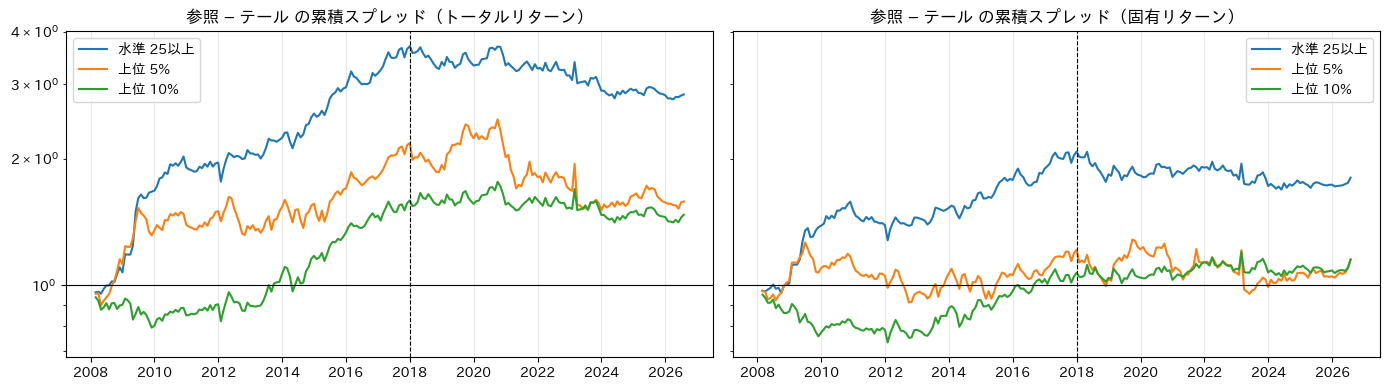

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, (col, label) in zip(axes, RETURN_COLS.items()):
    for k, z in spreads[col].items():
        rel = (1 + z.fillna(0)).cumprod()
        ax.plot(rel.index, rel, label=k)
    ax.axvline(pd.Timestamp(SPLIT), color="k", linestyle="--", linewidth=0.8)
    ax.axhline(1, color="k", linewidth=0.8)
    ax.set_yscale("log")
    ax.set_title(f"参照 − テール の累積スプレッド（{label}リターン）")
    ax.grid(alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()

In [6]:
ys = pd.DataFrame(
    {(label, k): z.groupby(z.index.year).apply(lambda x: (1 + x).prod() - 1) for col, label in RETURN_COLS.items() for k, z in spreads[col].items()}
)
ys.columns = pd.MultiIndex.from_tuples(ys.columns, names=["リターン", "定義"])
display(ys.round(3))

リターン    トータル                    固有              
定義   水準 25以上  上位 5% 上位 10% 水準 25以上  上位 5% 上位 10%
2008   0.073  0.122 -0.101   0.010  0.023 -0.134
2009   0.563  0.203 -0.109   0.373  0.074 -0.108
2010   0.135  0.030  0.059   0.088  0.016  0.038
2011   0.027  0.078  0.063  -0.078 -0.056 -0.023
2012   0.052 -0.092 -0.009   0.042 -0.089 -0.000
2013   0.088  0.127  0.191   0.055  0.113  0.127
2014   0.142  0.018  0.104   0.088 -0.033  0.044
2015   0.154  0.087  0.136   0.070  0.022  0.051
2016   0.080  0.068  0.097   0.065  0.028  0.068
2017   0.160  0.202  0.087   0.097  0.118  0.035
2018  -0.083 -0.113  0.001  -0.117 -0.145 -0.028
2019  -0.019  0.157 -0.019  -0.006  0.173  0.002
2020   0.001 -0.099 -0.004  -0.008 -0.116 -0.012
2021  -0.017 -0.103  0.026   0.053  0.055  0.102
2022  -0.037 -0.065 -0.041  -0.038 -0.055 -0.035
2023  -0.080 -0.108 -0.040  -0.060 -0.077 -0.020
2024   0.002  0.084  0.014   0.016  0.080  0.029
2025  -0.027 -0.037 -0.026  -0.009 -0.017 -0.017
2026   0.005  0.006  0.013   0.040  0.099  0.060

### 3. 25 以上の内訳: ファクター寄与と固有寄与

「参照 − 25 以上」のスプレッドを、固有リターン分（`srtn` のスプレッド）と残り（`rtn` − `srtn`、ファクターで説明される分）に分ける。

In [7]:
decomp = {}
for pname, per in PERIODS.items():
    total = period_slice(spreads["rtn"]["水準 25以上"], per).dropna()
    spec = period_slice(spreads["srtn"]["水準 25以上"], per).reindex(total.index)
    fac = total - spec
    decomp[pname] = {"トータル（年率）": total.mean() * 12, "固有（年率）": spec.mean() * 12, "ファクター（年率）": fac.mean() * 12, "固有の割合": spec.mean() / total.mean() if total.mean() != 0 else np.nan, "固有 R/R": spec.mean() / spec.std() * np.sqrt(12), "ファクター R/R": fac.mean() / fac.std() * np.sqrt(12)}
display(pd.DataFrame(decomp).round(3))

,全期間,前期 〜2017,後期 2018〜
トータル（年率）,0.062,0.139,-0.027
固有（年率）,0.036,0.078,-0.013
ファクター（年率）,0.026,0.061,-0.014
固有の割合,0.579,0.563,0.484
固有 R/R,0.391,0.820,-0.149
ファクター R/R,0.576,1.215,-0.372


### 4. IC（固有リターン）

翌月の固有リターンに対する IC。`06_regime` の `rtn` の値と比較する。

mean    std   icir  t_stat  hit_rate      n
定義             期間       リターン                                              
Spearman(−RRI) 全期間      トータル  0.012  0.114  0.108   1.610     0.532  222.0
               前期 〜2017 トータル  0.029  0.114  0.252   2.762     0.592  120.0
               後期 2018〜 トータル -0.007  0.112 -0.062  -0.622     0.461  102.0
25以上ダミー        全期間      トータル  0.011  0.090  0.126   1.873     0.550  222.0
               前期 〜2017 トータル  0.028  0.084  0.329   3.607     0.625  120.0
               後期 2018〜 トータル -0.008  0.093 -0.085  -0.859     0.461  102.0
上位10%ダミー       全期間      トータル  0.009  0.098  0.090   1.335     0.532  222.0
               前期 〜2017 トータル  0.018  0.102  0.176   1.933     0.583  120.0
               後期 2018〜 トータル -0.002  0.094 -0.021  -0.211     0.471  102.0
非ゼロダミー         全期間      トータル  0.012  0.105  0.111   1.661     0.509  222.0
               前期 〜2017 トータル  0.020  0.112  0.183   2.008     0.517  120.0
               後期 2018〜 トータル  0.002  0.097  0.016   0.159     0.500  102.0
Spearman(−RRI) 全期間      固有    0.009  0.106  0.089   1.332     0.509  222.0
               前期 〜2017 固有    0.015  0.107  0.138   1.510     0.533  120.0
               後期 2018〜 固有    0.003  0.104  0.031   0.311     0.480  102.0
25以上ダミー        全期間      固有    0.008  0.084  0.094   1.406     0.536  222.0
               前期 〜2017 固有    0.016  0.079  0.209   2.293     0.583  120.0
               後期 2018〜 固有   -0.002  0.089 -0.024  -0.239     0.480  102.0
上位10%ダミー       全期間      固有    0.005  0.091  0.049   0.737     0.495  222.0
               前期 〜2017 固有    0.006  0.093  0.062   0.677     0.500  120.0
               後期 2018〜 固有    0.003  0.090  0.034   0.346     0.490  102.0
非ゼロダミー         全期間      固有    0.011  0.101  0.113   1.690     0.545  222.0
               前期 〜2017 固有    0.014  0.106  0.133   1.459     0.558  120.0
               後期 2018〜 固有    0.008  0.094  0.087   0.880     0.529  102.0

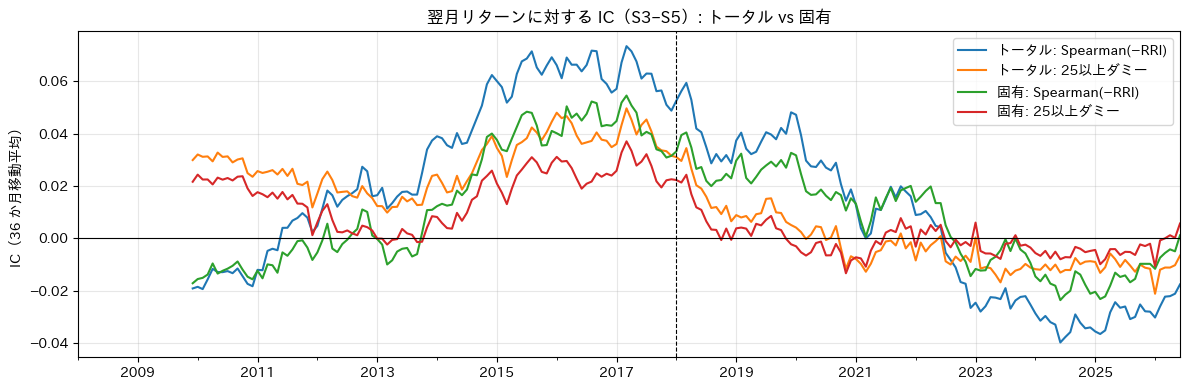

In [8]:
seg_univ = univ.where(seg)
ic_rows = {}
ic_series = {}
for col, label in RETURN_COLS.items():
    fwd1 = forward_returns(returns[col], 1)
    defs = {
        "Spearman(−RRI)": information_coefficient(-s_seg, fwd1, seg_univ, "spearman"),
        "25以上ダミー": information_coefficient(-tails["水準 25以上"].astype(float).where(scored), fwd1, seg_univ, "pearson"),
        "上位10%ダミー": information_coefficient(-tails["上位 10%"].astype(float).where(scored), fwd1, seg_univ, "pearson"),
        "非ゼロダミー": information_coefficient(-(s_seg > 0).astype(float).where(scored), fwd1, seg_univ, "pearson"),
    }
    for name, ic in defs.items():
        ic_series[(label, name)] = ic
        for pname, per in PERIODS.items():
            summ = ic_summary(period_slice(ic, per))
            ic_rows[(name, pname, label)] = summ[["mean", "std", "icir", "t_stat", "hit_rate", "n"]]
ic_tbl = pd.DataFrame(ic_rows).T
ic_tbl.index.names = ["定義", "期間", "リターン"]
display(ic_tbl.round(3))

ic_df = pd.DataFrame({f"{lab}: {name}": s for (lab, name), s in ic_series.items() if name in ("Spearman(−RRI)", "25以上ダミー")})
ax = ic_df.rolling(36, min_periods=24).mean().plot(figsize=(12, 4))
ax.axhline(0, color="k", linewidth=0.8)
ax.axvline(pd.Timestamp(SPLIT), color="k", linestyle="--", linewidth=0.8)
ax.set_ylabel("IC（36 か月移動平均）")
ax.set_title("翌月リターンに対する IC（S3–S5）: トータル vs 固有")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 5. 所見

**固有リターンの性質（S3〜S5）**

- `srtn` は `rtn` と銘柄 × 月で相関 0.78。銘柄リターンの月次標準偏差は 12.3% → 9.6% に下がり、
  クロスセクション平均の月次変動は 7.5% → 0.7% とほぼ消える（市場・ファクター寄与が除かれている）。
- ただし等ウェイト平均は月 +0.8% と正に偏る（時価総額加重で推定した残差を等ウェイトで平均しているため）。
  参照との差（スプレッド）ではこの偏りは相殺されるので、以下の比較には影響しない。

**参照 − 25 以上 のスプレッド（等ウェイト）**

| | トータル | 固有 | ファクター（差） |
| --- | --- | --- | --- |
| 前期 〜2017 年率 / R/R | +13.9% / 1.18 | +7.8% / 0.82 | +6.1% / 1.22 |
| 後期 2018〜 年率 / R/R | −2.7% / −0.29 | −1.3% / −0.15 | −1.4% / −0.37 |
| 全期間 年率 / R/R | +6.2% / 0.57 | +3.6% / 0.39 | +2.6% / 0.58 |

- 前期の劣後の **56% は固有リターン**（ファクターで説明されない銘柄固有の部分）で、R/R 0.82 と独立に有意。
  残り 44% は業種・サイズ・スタイルなどのファクター寄与（`06_regime` の業種中立分析と整合）。
- 後期は固有リターンでも効果が無い（−1.3%、勝率 48%）。年別では 2018 年 −12%、2023 年 −6% など負の年が多く、
  正の年（2021、2026）も小さい。

**順位定義のテール（上位 5% / 10%）**

- 固有リターンでは前期でも上位 5% が +2.6%（R/R 0.23）、上位 10% が +1.1%（R/R 0.12）と弱い。
  トータルリターンで見えていた順位テールの効果（+8.7% / +5.2%）の大半はファクター寄与だった。
- 「25 以上」という水準には固有リターンの情報があったが、順位上位というだけでは無かった。

**IC（翌月固有リターン）**

| 定義 | 前期 mean / t 値 | 後期 mean / t 値 |
| --- | --- | --- |
| 25 以上ダミー | 0.016 / 2.3 | −0.002 / −0.2 |
| Spearman（−RRI） | 0.015 / 1.5 | 0.003 / 0.3 |
| 上位 10% ダミー | 0.006 / 0.7 | 0.003 / 0.3 |
| 非ゼロダミー | 0.014 / 1.5 | 0.008 / 0.9 |

- トータルでは前期の 25 以上ダミーが t 値 3.6 だったのに対し、固有では 2.3。有意ではあるが弱まる。
- 後期はどの定義でも符号が消える。非ゼロダミーだけが後期も僅かに正（t 値 0.9）だが有意ではない。

**まとめ**

1. 前期（2008〜2017 年）の「RRI 25 以上の劣後」は、ファクターに還元されない固有リターンの成分を半分強含んでおり、
   当時はレピュテーションリスクが銘柄固有の価格情報だったと解釈できる。
2. 後期（2018 年〜）は固有リターンでも消失。ファクター構成の変化では説明できず、`06_regime` の結論
   （レジーム変化または情報の織り込み）が固有リターンでも確認された。
3. 「25 以上」の水準に情報があり、順位テールには無い。RepRisk の「中」以上という区分がレピュテーション事案の
   有無に対応しているためで、スクリーンとして使うなら水準ベースが妥当。ただし現状では後期の裏付けが無い。

**後続ステップ**

- 水準ではなく**変化**（RRI の上昇、新規に 25 以上になった直後）に固有リターンの反応が残っているかを確認する。
  事案発生直後の反応は、水準の織り込みとは別に残っている可能性がある。
- 後期に情報が残らない場合は、RRI をリターン予測から外し、リスク管理（除外）用途の税引後コスト評価に進む。